# Model selection

## 1 Splice classification

In [19]:
from sklearn.datasets import load_svmlight_file
import numpy as np
X, Y = load_svmlight_file("./splice")
print(f"nombre de samples: {X.shape[0]}, nombre de features: {X.shape[1]}\n")
Y[Y < 0] = 0
unique, count = np.unique(Y, return_counts=True)
for u, c in zip(unique, count):
    print(f"classe {u}: {c} samples")
    pourcentage_classe1 = c/X.shape[0]
    print(f"pourcentage classe {u}: {pourcentage_classe1*100}%")

nombre de samples: 1000, nombre de features: 60

classe 0.0: 483 samples
pourcentage classe 0.0: 48.3%
classe 1.0: 517 samples
pourcentage classe 1.0: 51.7%


In [62]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, 
                                                    shuffle=True, test_size=1/3)

gamma_grid = np.logspace(-3, 0, 25) 
C_grid = np.logspace(-1/2, 2, 25)
parameters = {'kernel':['rbf'], 'C':C_grid, 'gamma':gamma_grid}
svc_rbf = SVC(kernel="rbf", tol=0.01)
K = 3
clf_rbf = GridSearchCV(svc_rbf, param_grid=parameters, cv=K, 
                  scoring="accuracy", verbose=1, n_jobs=2)
clf_rbf.fit(X_train, Y_train)

Fitting 3 folds for each of 625 candidates, totalling 1875 fits


GridSearchCV(cv=3, estimator=SVC(tol=0.01), n_jobs=2,
             param_grid={'C': array([  0.31622777,   0.40194503,   0.51089698,   0.64938163,
         0.82540419,   1.04913973,   1.33352143,   1.69498815,
         2.15443469,   2.73841963,   3.48070059,   4.42418555,
         5.62341325,   7.14770577,   9.08517576,  11.54781985,
        14.67799268,  18.65663579,  23.71373706,  30.1416253 ,
        38.3118685 ,  48.69675252,  61.89658189,  78.67438077,
       100.        ]),
                         'gamma': array([0.001     , 0.00133352, 0.00177828, 0.00237137, 0.00316228,
       0.00421697, 0.00562341, 0.00749894, 0.01      , 0.01333521,
       0.01778279, 0.02371374, 0.03162278, 0.04216965, 0.05623413,
       0.07498942, 0.1       , 0.13335214, 0.17782794, 0.23713737,
       0.31622777, 0.4216965 , 0.56234133, 0.74989421, 1.        ]),
                         'kernel': ['rbf']},
             scoring='accuracy', verbose=1)


 Rbf kernel - optimal hyper-parameters = {'C': 1.0491397291363098, 'gamma': 0.01778279410038923, 'kernel': 'rbf'}

 Rbf kernel - best cross-val accuracy = 0.8723723723723724


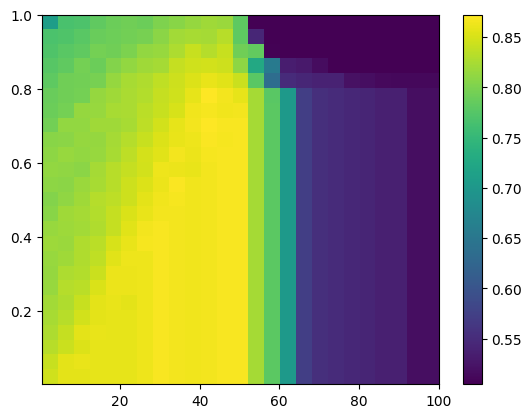

In [63]:
print("\n Rbf kernel - optimal hyper-parameters = {}".format(clf_rbf.best_params_))
print("\n Rbf kernel - best cross-val accuracy = {}".format(clf_rbf.best_score_))

import matplotlib.pyplot as plt
plt.imshow(clf_rbf.cv_results_["mean_test_score"].reshape(C_grid.shape[0],
                                                           gamma_grid.shape[0]),                                                           
           extent=[min(C_grid),max(C_grid),min(gamma_grid),max(gamma_grid)],
           interpolation=None,
           aspect="auto")
plt.colorbar()
plt.show()

In [69]:
unique, count = np.unique(Y_test, return_counts=True)
for u, c in zip(unique, count):
    print(f"classe {u}: {c} samples")
    pourcentage_classe1 = c/X.shape[0]
    print(f"pourcentage classe {u}: {pourcentage_classe1*100}%")

classe 0.0: 147 samples
pourcentage classe 0.0: 14.7%
classe 1.0: 187 samples
pourcentage classe 1.0: 18.7%


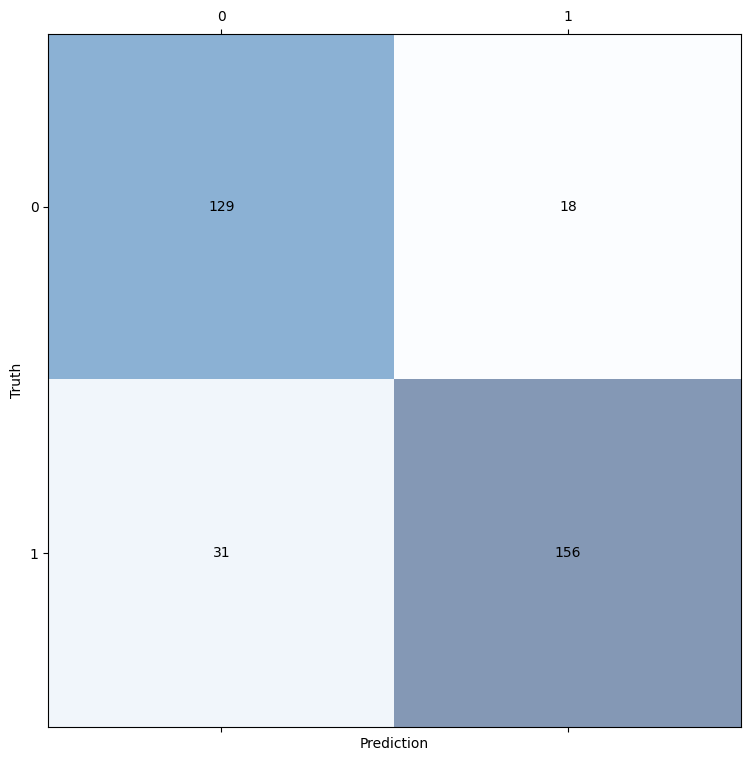

In [68]:
from sklearn.metrics import confusion_matrix, accuracy_score

svc_rbf = SVC(C = 1.0491397291363098, gamma = 0.01778279410038923, kernel='rbf')
svc_rbf.fit(X_train, Y_train)
Ytest_pred = svc_rbf.predict(X_test)
confmat = confusion_matrix(Y_test, Ytest_pred)
fig, ax = plt.subplots(figsize=(9, 9))
ax.matshow(confmat, cmap=plt.cm.Blues, alpha=0.5)
for i in range(confmat.shape[0]):
    for j in range(confmat.shape[1]):
        ax.text(x=j, y=i, s=confmat[i, j], va="center", ha="center")
plt.xlabel("Prediction"); plt.ylabel("Truth");

In [70]:
C_grid = np.logspace(-0.5, 2, 25) 
parameters_linear = {'kernel':['linear'], 'C':C_grid}

clf_linear = GridSearchCV(SVC(kernel="linear", tol=0.01, random_state=42), 
                          param_grid=parameters_linear, cv=3, scoring="accuracy", n_jobs=2)
clf_linear.fit(X_train, Y_train)

accuracy_linear_cv = clf_linear.best_score_
accuracy_linear_test = accuracy_score(Y_test, clf_linear.predict(X_test))

# ne pas mettre ça mais les nouveaux paramètres du linear svm plutôt car ca c'est les meilleurs params de kernel svm 

C_rbf = 1.0491397291363098
gamma_rbf = 0.01778279410038923
svc_rbf = SVC(C = C_rbf, gamma = gamma_rbf, kernel='rbf', tol=0.01, random_state=42)
svc_rbf.fit(X_train, Y_train)
accuracy_rbf_test = accuracy_score(Y_test, svc_rbf.predict(X_test))


# plot un graphique de la différence pour le taux d'erreur pour 
print(f"SVM Linéaire (Meilleure VC): {accuracy_linear_cv:.4f}")
print(f"SVM Linéaire (Précision Test): {accuracy_linear_test:.4f}")

SVM Linéaire (Meilleure VC): 0.7958
SVM Linéaire (Précision Test): 0.7844
SVM RBF (Précision Test, C=1.049, gamma=0.0178): 0.8563
